# Face Mask and Emotion Detection - EDA and Preprocessing

in this notebook i will:
- load the two datasets (face mask and fer2013)
- clean the data (remove duplicates, fix corrupted images)
- explore the data with some charts
- handle class imbalance

the two datasets i used:
- face mask dataset from kaggle (andrewmvd)
- fer2013 emotion dataset from kaggle

## install libraries

In [1]:
# first install what we need
!pip install opendatasets albumentations opencv-python-headless -q

In [2]:
# import everything
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

print('all imports done')

all imports done


## Step 1 - Download and Load the Datasets

In [3]:
# download datasets from kaggle
# you need to enter your kaggle username and key when asked
# get the key from kaggle.com -> settings -> API -> Create New Token

import opendatasets as od

od.download('https://www.kaggle.com/datasets/andrewmvd/face-mask-detection')
od.download('https://www.kaggle.com/datasets/msambare/fer2013')

print('datasets downloaded')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: topmoviesdfhd
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection


100%|██████████| 398M/398M [00:20<00:00, 20.6MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: topmoviesdfhd
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013


100%|██████████| 60.3M/60.3M [00:03<00:00, 16.0MB/s]



datasets downloaded


In [4]:
# set folder paths
MASK_IMG_DIR  = Path('face-mask-detection/images')
MASK_ANNO_DIR = Path('face-mask-detection/annotations')
FER_DIR       = Path('fer2013')

EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print('mask images folder:', MASK_IMG_DIR)
print('fer2013 folder:', FER_DIR)

mask images folder: face-mask-detection/images
fer2013 folder: fer2013


In [5]:
# the mask dataset uses xml annotation files
# each xml file has bounding boxes and labels (with_mask, without_mask, mask_weared_incorrect)
# i will read them and make a dataframe

def read_mask_xml(anno_dir):
    rows = []
    # map all labels to just 2 classes: with_mask=1, without_mask=0
    label_map = {
        'with_mask': 1,
        'without_mask': 0,
        'mask_weared_incorrect': 0
    }
    for xml_file in sorted(anno_dir.glob('*.xml')):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        filename = root.find('filename').text
        for obj in root.findall('object'):
            label_str = obj.find('name').text.strip().lower()
            label = label_map.get(label_str, 0)
            rows.append({'filename': filename, 'label': label, 'label_name': label_str})
    return pd.DataFrame(rows)

mask_df = read_mask_xml(MASK_ANNO_DIR)
print('mask dataset shape:', mask_df.shape)
print(mask_df['label_name'].value_counts())
mask_df.head()

mask dataset shape: (4072, 3)
label_name
with_mask                3232
without_mask              717
mask_weared_incorrect     123
Name: count, dtype: int64


,filename,label,label_name
0,maksssksksss0.png,0,without_mask
1,maksssksksss0.png,1,with_mask
2,maksssksksss0.png,0,without_mask
3,maksssksksss1.png,1,with_mask
4,maksssksksss1.png,1,with_mask


In [6]:
# for fer2013, the folder structure is already train/emotion_name/
# so i just need to get all file paths and labels

def load_fer_paths(fer_dir, split='train'):
    rows = []
    for label_idx, emotion in enumerate(EMOTION_LABELS):
        folder = fer_dir / split / emotion
        if not folder.exists():
            continue
        for img_path in folder.glob('*.jpg'):
            rows.append({
                'filepath': str(img_path),
                'label': label_idx,
                'emotion': emotion,
                'split': split  # FIX: keep track of train/test so cleaning survives into training
            })
    return pd.DataFrame(rows)

fer_train = load_fer_paths(FER_DIR, 'train')
fer_test  = load_fer_paths(FER_DIR, 'test')
fer_df    = pd.concat([fer_train, fer_test], ignore_index=True)

print('fer2013 total images:', len(fer_df))
print(fer_df['emotion'].value_counts())
fer_df.head()


fer2013 total images: 35887
emotion
happy       8989
neutral     6198
sad         6077
fear        5121
angry       4953
surprise    4002
disgust      547
Name: count, dtype: int64


,filepath,label,emotion,split
0,fer2013/train/angry/Training_73833007.jpg,0,angry,train
1,fer2013/train/angry/Training_86407057.jpg,0,angry,train
2,fer2013/train/angry/Training_71156584.jpg,0,angry,train
3,fer2013/train/angry/Training_82660355.jpg,0,angry,train
4,fer2013/train/angry/Training_16594897.jpg,0,angry,train


## Step 2 - Remove Duplicate Images

i will use MD5 hashing to find images that are exactly the same.
if two images have the same hash, they are identical, so i will keep only one.

In [7]:
def get_md5(filepath):
    # read the image bytes and compute a hash
    try:
        with open(filepath, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

# check duplicates in fer2013
print('checking for duplicates in fer2013...')
fer_df['hash'] = fer_df['filepath'].apply(get_md5)

before = len(fer_df)
fer_df.drop_duplicates(subset='hash', inplace=True)
after = len(fer_df)

print(f'before: {before} images')
print(f'after removing duplicates: {after} images')
print(f'removed: {before - after} duplicate images')

checking for duplicates in fer2013...
before: 35887 images
after removing duplicates: 34034 images
removed: 1853 duplicate images


In [8]:
# check duplicates in mask dataset
mask_img_list = list(MASK_IMG_DIR.glob('*.png')) + list(MASK_IMG_DIR.glob('*.jpg'))

seen_hashes = {}
duplicate_count = 0

for img_path in mask_img_list:
    h = get_md5(img_path)
    if h in seen_hashes:
        duplicate_count += 1
    else:
        seen_hashes[h] = img_path

print(f'mask dataset: {len(mask_img_list)} total images')
print(f'duplicates found: {duplicate_count}')

mask dataset: 853 total images
duplicates found: 5


## Step 3 - Handle Corrupted or Missing Files

some images in the dataset might be broken or missing.
i will check each image and if it cant be opened i will remove it.
if less than 5% are broken its safe to just drop them.

In [9]:
def is_valid_image(filepath):
    # try opening the image, if it fails its corrupted
    try:
        img = Image.open(filepath)
        img.verify()
        return True
    except:
        return False

print('checking image integrity... (this takes a moment)')
fer_df['is_valid'] = fer_df['filepath'].apply(is_valid_image)

corrupted = fer_df[~fer_df['is_valid']]
pct = len(corrupted) / len(fer_df) * 100

print(f'corrupted images: {len(corrupted)} ({pct:.2f}%)')

if pct < 5:
    print('less than 5% corrupted -> safe to drop them')
    fer_df = fer_df[fer_df['is_valid']].reset_index(drop=True)
    print(f'clean dataset size: {len(fer_df)}')
else:
    print('WARNING: more than 5% corrupted, need to investigate!')

checking image integrity... (this takes a moment)
corrupted images: 0 (0.00%)
less than 5% corrupted -> safe to drop them
clean dataset size: 34034


## Step 4 - Detect Outlier Images (blank or wrong size)

outliers can be:
- images with very low pixel variation (basically blank)
- images with unusual sizes

i will look at a sample and visualize what outliers look like vs normal images.

In [10]:
def get_img_info(filepath):
    # get width, height, and pixel std (low std = blank image)
    try:
        img = cv2.imread(str(filepath))
        if img is None:
            return None
        h, w = img.shape[:2]
        std_px = img.std()  # how much the pixels vary
        return w, h, std_px
    except:
        return None

# check a sample of 500 images
sample = fer_df['filepath'].sample(500, random_state=42).tolist()
info_list = [get_img_info(p) for p in sample]
info_list = [x for x in info_list if x is not None]

widths = [x[0] for x in info_list]
heights = [x[1] for x in info_list]
stds = [x[2] for x in info_list]

# images with std < 5 are basically blank
blank_count = sum(1 for s in stds if s < 5)
print(f'possibly blank images in sample: {blank_count}')
print(f'most common sizes:', Counter(zip(widths, heights)).most_common(3))

possibly blank images in sample: 0
most common sizes: [((48, 48), 500)]


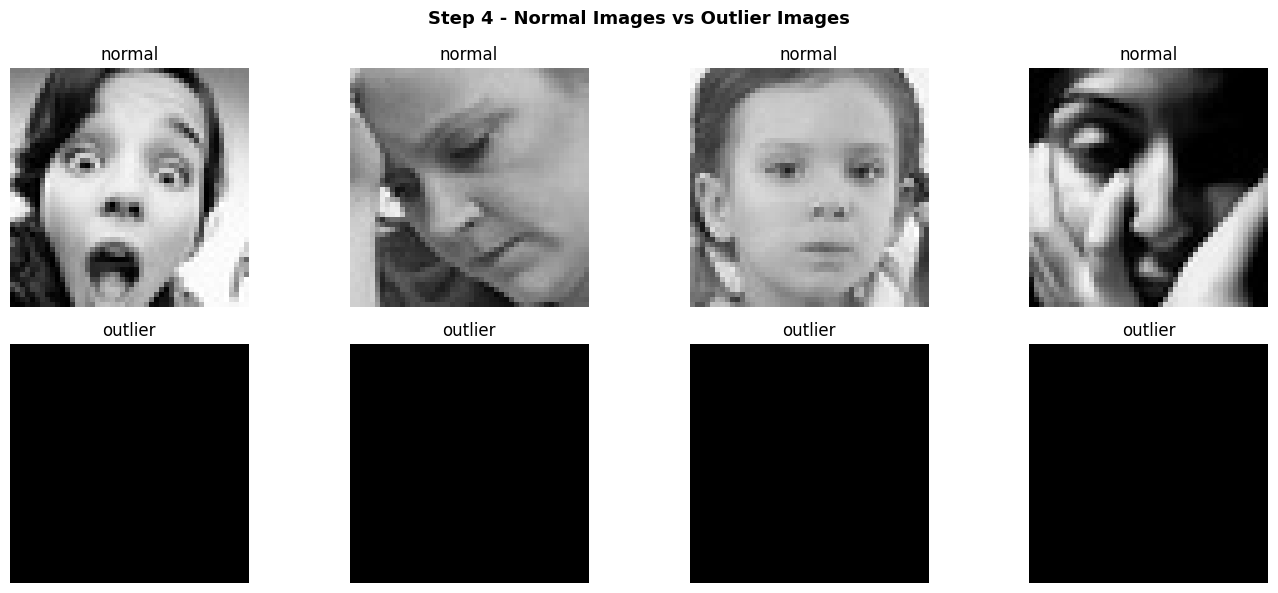

saved to outputs/step4_outliers.png


In [11]:
# show what normal vs blank images look like
normal_paths = [p for p, s in zip(sample, stds) if s >= 10][:4]
blank_paths  = [p for p, s in zip(sample, stds) if s < 10][:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Step 4 - Normal Images vs Outlier Images', fontsize=13, fontweight='bold')

for i, p in enumerate(normal_paths):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img)
    axes[0][i].set_title('normal')
    axes[0][i].axis('off')

for i, p in enumerate(blank_paths + [None] * 4):  # pad if not enough blanks
    if p:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        axes[1][i].imshow(img)
    else:
        axes[1][i].imshow(np.zeros((48, 48, 3), dtype=np.uint8))
    axes[1][i].set_title('outlier')
    axes[1][i].axis('off')

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/step4_outliers.png')
plt.show()
print('saved to outputs/step4_outliers.png')

## Step 5 - EDA and Visualizations

now i will make some charts to understand the data better.
i will make 7 plots total.

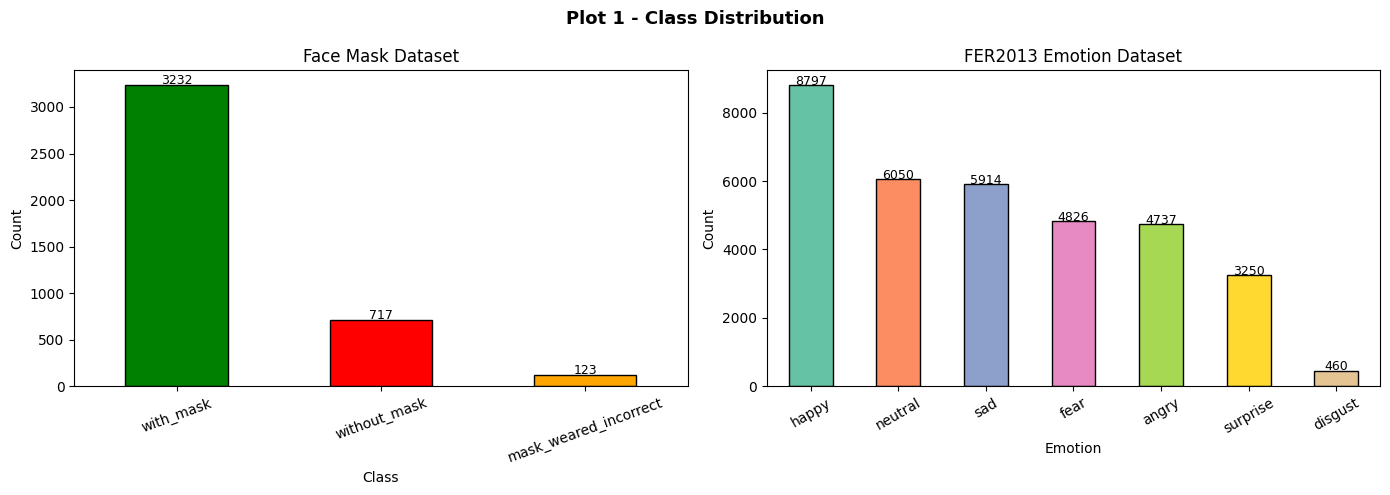

plot 1 done


In [12]:
# plot 1 - class distribution for both datasets

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 1 - Class Distribution', fontsize=13, fontweight='bold')

# mask dataset
mask_counts = mask_df['label_name'].value_counts()
mask_counts.plot(kind='bar', ax=axes[0], color=['green', 'red', 'orange'], edgecolor='black')
axes[0].set_title('Face Mask Dataset')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 10,
                 str(int(p.get_height())), ha='center', fontsize=9)

# emotion dataset
emo_counts = fer_df['emotion'].value_counts()
emo_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[1].set_title('FER2013 Emotion Dataset')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 10,
                 str(int(p.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plot1_class_distribution.png')
plt.show()
print('plot 1 done')

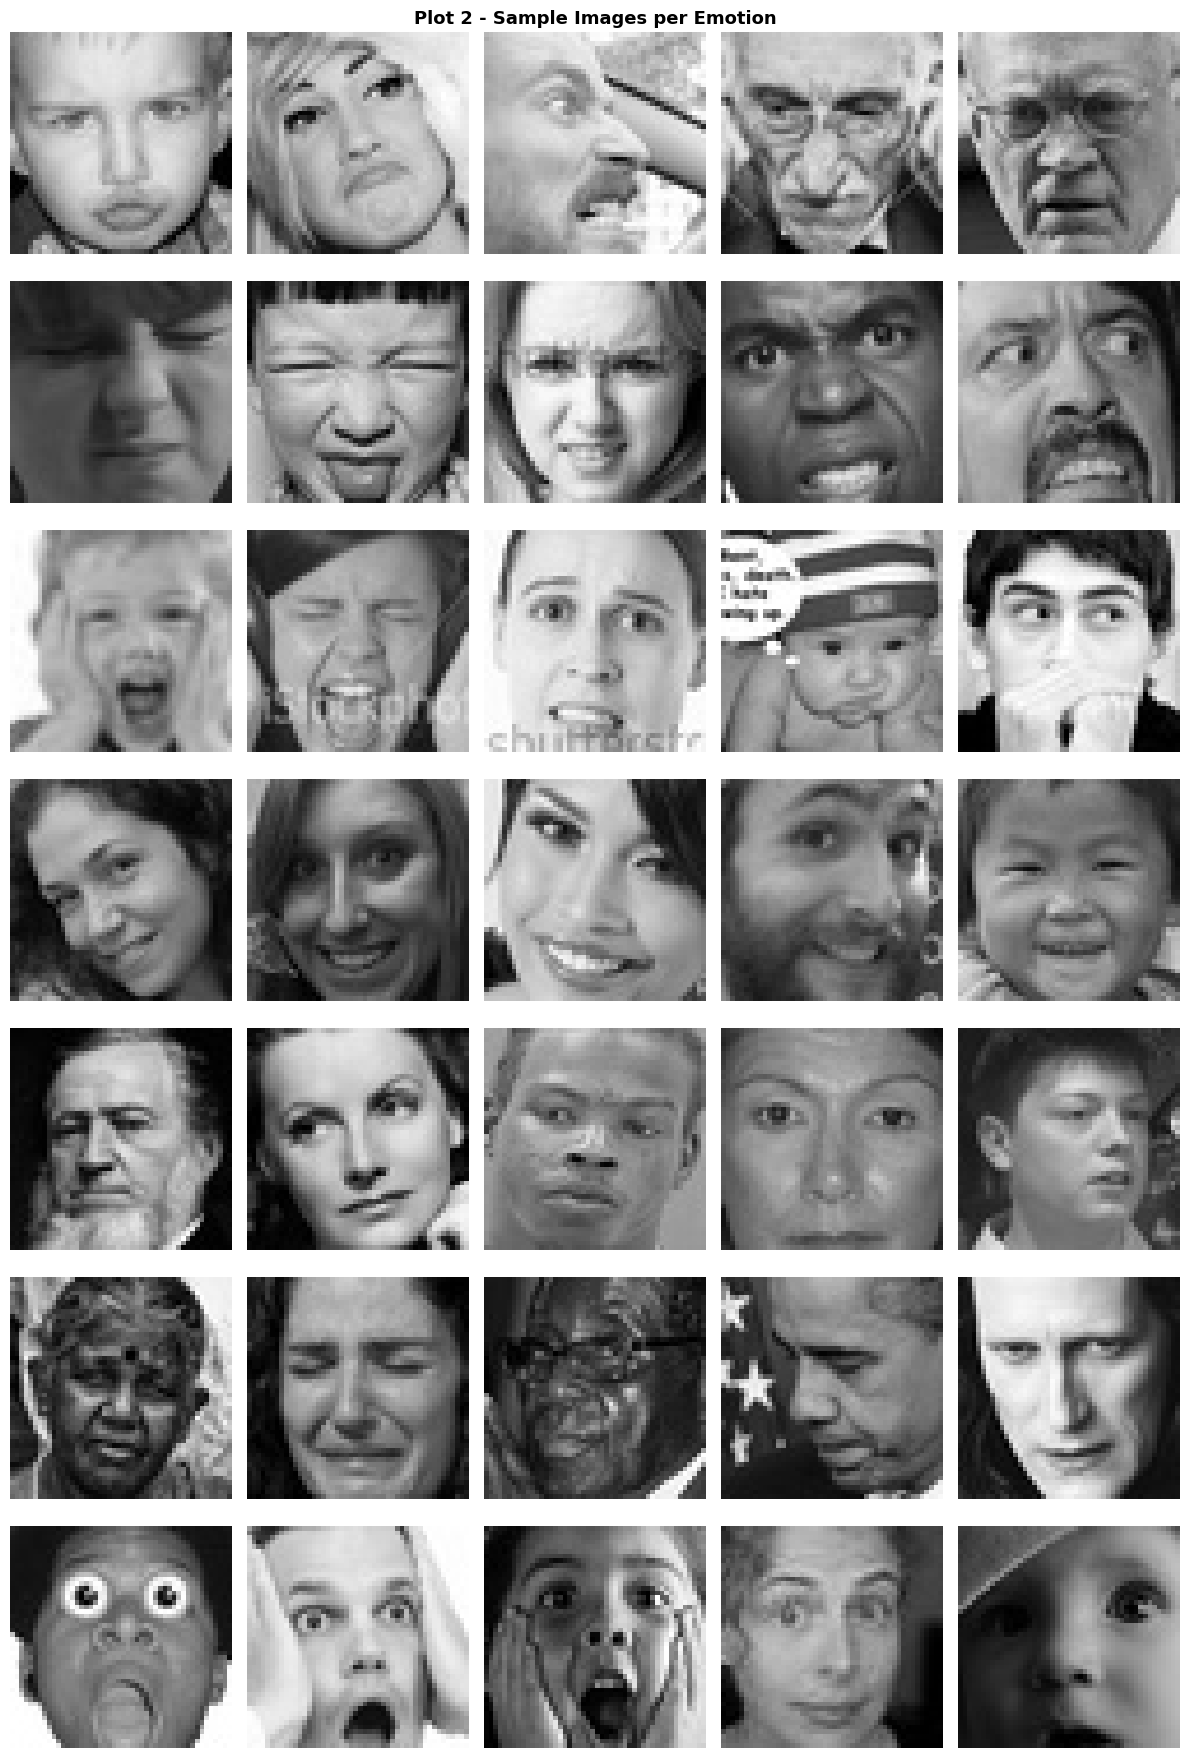

plot 2 done


In [13]:
# plot 2 - sample images for each emotion class
fig, axes = plt.subplots(7, 5, figsize=(12, 18))
fig.suptitle('Plot 2 - Sample Images per Emotion', fontsize=13, fontweight='bold')

for row, emotion in enumerate(EMOTION_LABELS):
    subset = fer_df[fer_df['emotion'] == emotion]['filepath'].sample(5, random_state=42)
    for col, path in enumerate(subset):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = np.zeros((48, 48, 3), dtype=np.uint8)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(emotion, fontsize=9, fontweight='bold',
                                       rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.savefig('outputs/plot2_sample_grid.png')
plt.show()
print('plot 2 done')

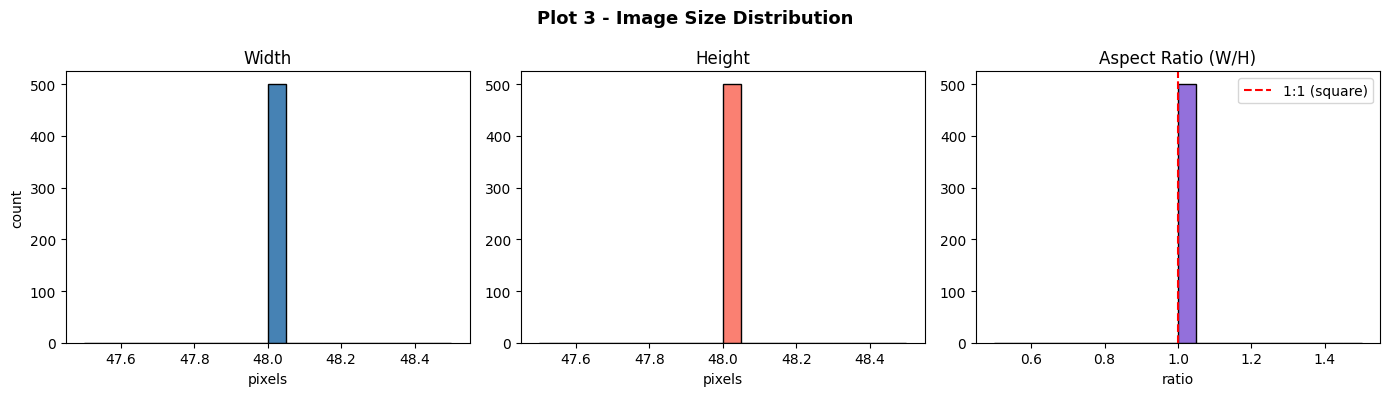

plot 3 done


In [14]:
# plot 3 - image size distribution
# how big are the images? are they all the same size?

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Plot 3 - Image Size Distribution', fontsize=13, fontweight='bold')

axes[0].hist(widths, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Width')
axes[0].set_xlabel('pixels')
axes[0].set_ylabel('count')

axes[1].hist(heights, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Height')
axes[1].set_xlabel('pixels')

aspect_ratios = [w/h for w, h in zip(widths, heights)]
axes[2].hist(aspect_ratios, bins=20, color='mediumpurple', edgecolor='black')
axes[2].set_title('Aspect Ratio (W/H)')
axes[2].set_xlabel('ratio')
axes[2].axvline(1.0, color='red', linestyle='--', label='1:1 (square)')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/plot3_size_distribution.png')
plt.show()
print('plot 3 done')

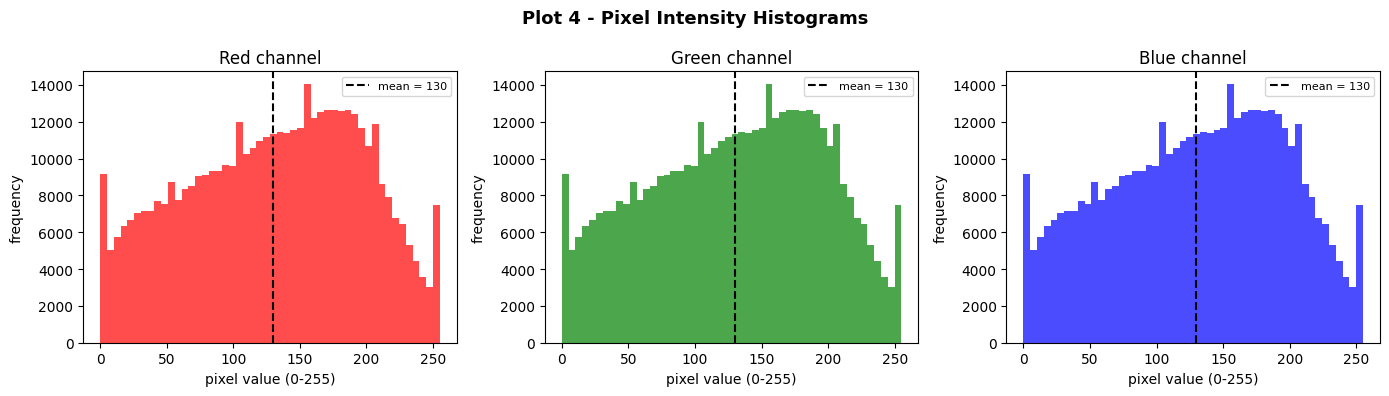

plot 4 done


In [15]:
# plot 4 - pixel intensity for each color channel (R, G, B)
# this shows if the dataset is mostly dark or bright

R_vals, G_vals, B_vals = [], [], []

for path in fer_df['filepath'].sample(200, random_state=42):
    img = cv2.imread(path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (48, 48))
    R_vals.extend(img[:, :, 0].flatten().tolist())
    G_vals.extend(img[:, :, 1].flatten().tolist())
    B_vals.extend(img[:, :, 2].flatten().tolist())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Plot 4 - Pixel Intensity Histograms', fontsize=13, fontweight='bold')

for ax, vals, color, label in zip(axes, [R_vals, G_vals, B_vals],
                                   ['red', 'green', 'blue'], ['Red', 'Green', 'Blue']):
    ax.hist(vals, bins=50, color=color, alpha=0.7, edgecolor='none')
    ax.set_title(f'{label} channel')
    ax.set_xlabel('pixel value (0-255)')
    ax.set_ylabel('frequency')
    ax.axvline(np.mean(vals), color='black', linestyle='--',
               label=f'mean = {np.mean(vals):.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plot4_pixel_intensity.png')
plt.show()
print('plot 4 done')

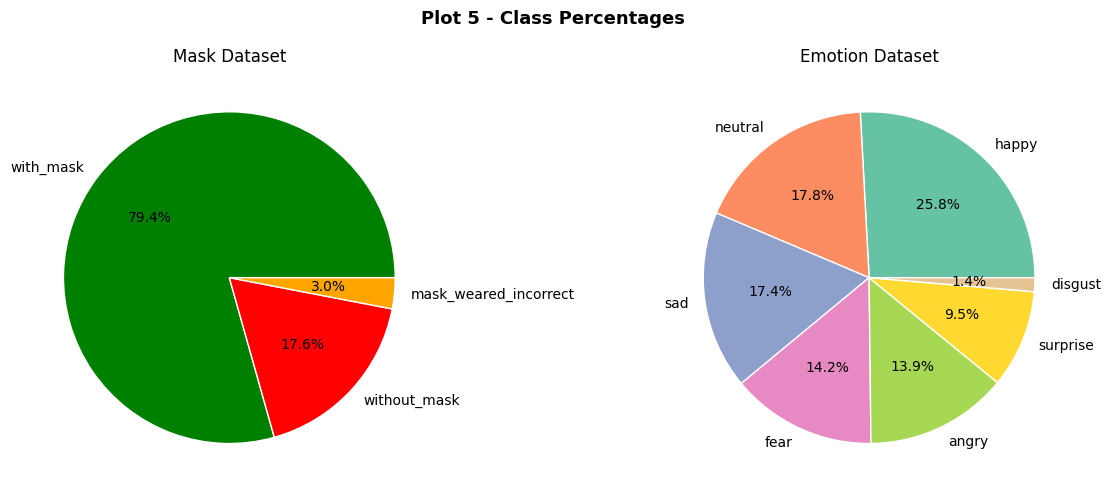

plot 5 done


In [16]:
# plot 5 - pie charts for class percentages

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Plot 5 - Class Percentages', fontsize=13, fontweight='bold')

mask_c = mask_df['label_name'].value_counts()
axes[0].pie(mask_c, labels=mask_c.index, autopct='%1.1f%%',
            colors=['green', 'red', 'orange'],
            wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Mask Dataset')

emo_c = fer_df['emotion'].value_counts()
axes[1].pie(emo_c, labels=emo_c.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(emo_c)),
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Emotion Dataset')

plt.tight_layout()
plt.savefig('outputs/plot5_class_percentages.png')
plt.show()
print('plot 5 done')

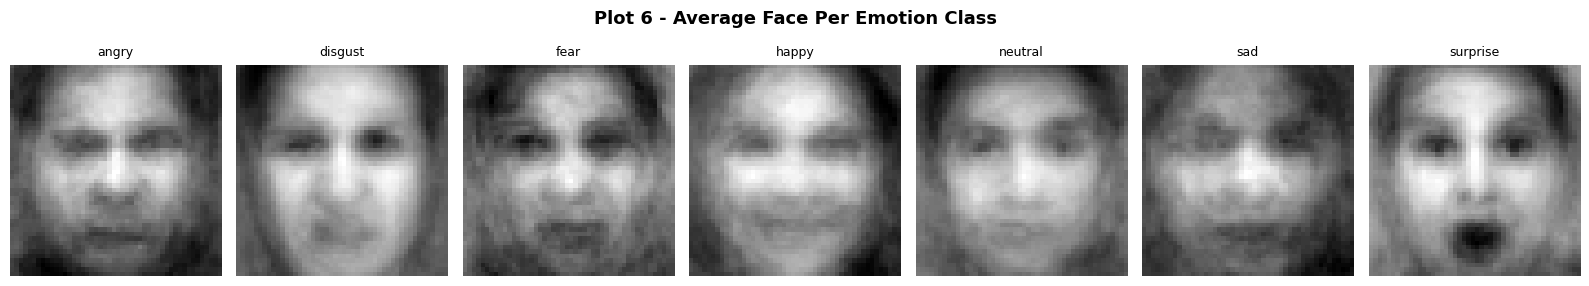

plot 6 done


In [17]:
# plot 6 - average face per emotion
# i average all the pixel values for each emotion to see what the "typical" face looks like

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
fig.suptitle('Plot 6 - Average Face Per Emotion Class', fontsize=13, fontweight='bold')

for ax, emotion in zip(axes, EMOTION_LABELS):
    paths = fer_df[fer_df['emotion'] == emotion]['filepath'].head(100).tolist()
    images = []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(cv2.resize(img, (48, 48)).astype('float32'))
    if images:
        mean_face = np.mean(images, axis=0).astype('uint8')
        ax.imshow(mean_face, cmap='gray')
    ax.set_title(emotion, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/plot6_average_faces.png')
plt.show()
print('plot 6 done')

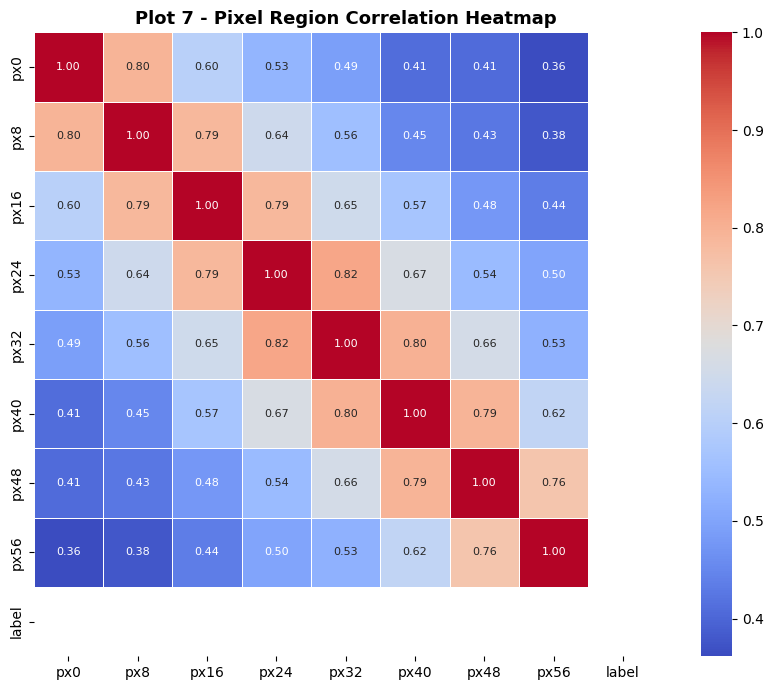

plot 7 done


In [18]:
# plot 7 - correlation heatmap between pixel regions and emotion label
# i flatten each image to small 8x8 pixels and check how correlated each region is with the label

feature_rows = []
for p, emo in zip(fer_df['filepath'].head(400), fer_df['emotion'].head(400)):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    resized = cv2.resize(img, (8, 8)).flatten()
    feature_rows.append(list(resized) + [EMOTION_LABELS.index(emo)])

feat_df = pd.DataFrame(feature_rows,
                        columns=[f'px{i}' for i in range(64)] + ['label'])

# pick every 8th pixel plus the label to keep the heatmap readable
cols = [f'px{i}' for i in range(0, 64, 8)] + ['label']
corr = feat_df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True, annot_kws={'size': 8})
ax.set_title('Plot 7 - Pixel Region Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plot7_correlation_heatmap.png')
plt.show()
print('plot 7 done')

## Step 6 - Handle Class Imbalance

some emotions appear much more than others (happy is common, disgust is rare).
i will handle this in two ways:
1. compute class weights so the model pays more attention to rare classes
2. use data augmentation with albumentations to create more variety

In [19]:
# show class percentages clearly
print('FER2013 class distribution')
emo_val = fer_df['emotion'].value_counts()
for emo, count in emo_val.items():
    pct = count / len(fer_df) * 100
    print(f'  {emo:10s}: {count:5d}  ({pct:.1f}%)')

print('\nmask dataset class distribution')
mask_val = mask_df['label_name'].value_counts()
for cls, count in mask_val.items():
    pct = count / len(mask_df) * 100
    print(f'  {cls:25s}: {count:4d}  ({pct:.1f}%)')

FER2013 class distribution
  happy     :  8797  (25.8%)
  neutral   :  6050  (17.8%)
  sad       :  5914  (17.4%)
  fear      :  4826  (14.2%)
  angry     :  4737  (13.9%)
  surprise  :  3250  (9.5%)
  disgust   :   460  (1.4%)

mask dataset class distribution
  with_mask                : 3232  (79.4%)
  without_mask             :  717  (17.6%)
  mask_weared_incorrect    :  123  (3.0%)


In [20]:
# compute class weights for the emotion classes
# these weights will be passed to model.fit() so rarer classes get more importance

all_labels = fer_df['label'].values
unique_labels = np.unique(all_labels)

weights = compute_class_weight('balanced', classes=unique_labels, y=all_labels)
class_weights = dict(zip(unique_labels, weights))

print('class weights for emotion model:')
for k, v in class_weights.items():
    print(f'  class {k} ({EMOTION_LABELS[k]}): weight = {v:.4f}')

# save for use in training notebook
print('\nwe will pass this dict to model.fit(class_weight=class_weights)')

class weights for emotion model:
  class 0 (angry): weight = 1.0264
  class 1 (disgust): weight = 10.5696
  class 2 (fear): weight = 1.0075
  class 3 (happy): weight = 0.5527
  class 4 (neutral): weight = 0.8036
  class 5 (sad): weight = 0.8221
  class 6 (surprise): weight = 1.4960

we will pass this dict to model.fit(class_weight=class_weights)


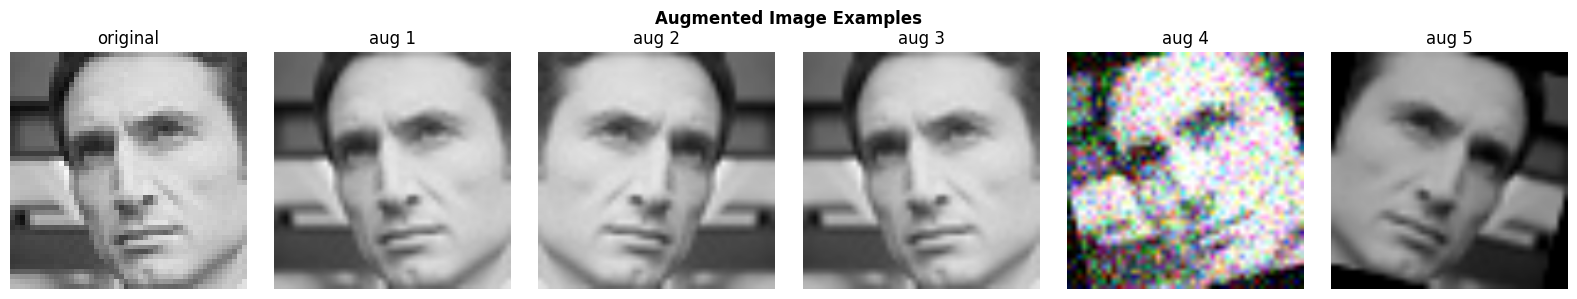

augmentation examples saved


In [21]:
# define albumentations augmentation pipeline
# this will generate modified versions of training images

augment = A.Compose([
    A.HorizontalFlip(p=0.5),           # flip left-right
    A.Rotate(limit=15, p=0.4),          # small rotation
    A.RandomBrightnessContrast(p=0.4),  # change brightness/contrast
    A.GaussNoise(var_limit=(5, 25), p=0.2),  # add noise
    A.Resize(224, 224),                 # resize for model input
])

# show 5 augmented versions of one image
sample_img = cv2.cvtColor(cv2.imread(fer_df['filepath'].iloc[0]), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img)
axes[0].set_title('original')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = augment(image=sample_img)['image']
    axes[i].imshow(aug_img)
    axes[i].set_title(f'aug {i}')
    axes[i].axis('off')

plt.suptitle('Augmented Image Examples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plot6b_augmentation_examples.png')
plt.show()
print('augmentation examples saved')

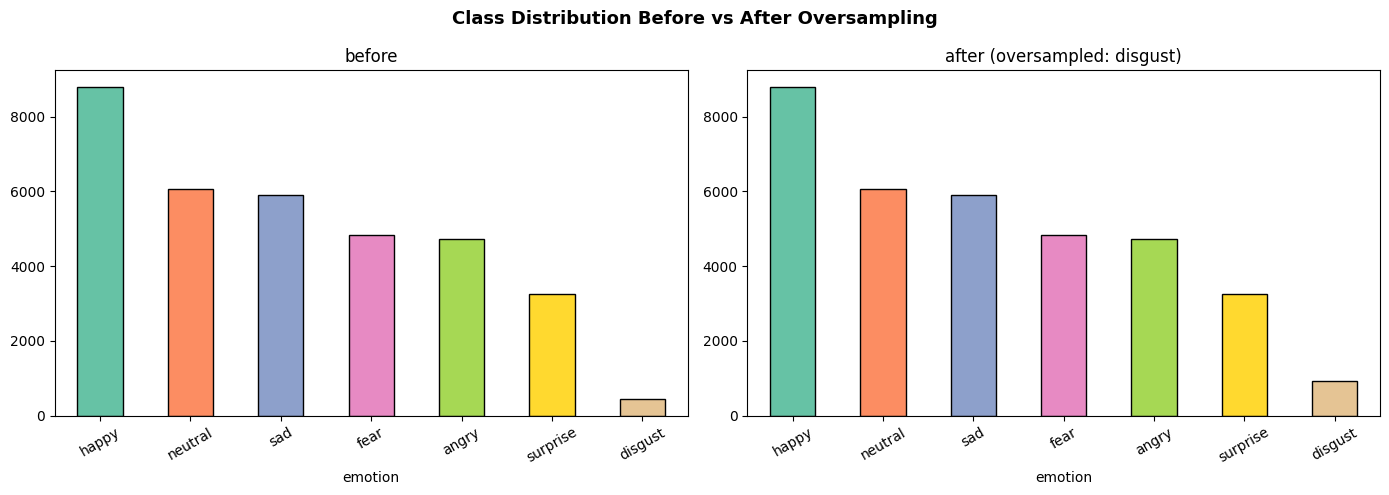

done


In [22]:
# show before/after oversampling - just to illustrate the concept
before_counts = fer_df['emotion'].value_counts().copy()

minority_class = before_counts.idxmin()
minority_rows  = fer_df[fer_df['emotion'] == minority_class]

# oversample the minority class by duplicating it
oversampled_df = pd.concat([fer_df, minority_rows.sample(len(minority_rows),
                                                          replace=True, random_state=42)])
after_counts = oversampled_df['emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Before vs After Oversampling', fontsize=13, fontweight='bold')

before_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[0].set_title('before')
axes[0].tick_params(axis='x', rotation=30)

after_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[1].set_title(f'after (oversampled: {minority_class})')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/plot6c_before_after_oversampling.png')
plt.show()
print('done')

## Summary

what i did in this notebook:

| step | what i did |
|------|------------|
| 1 | loaded face mask dataset (from XML) and FER2013 dataset |
| 2 | found and removed duplicate images using MD5 hashing |
| 3 | checked for corrupted files and dropped them (less than 5%) |
| 4 | found outlier images (blank/wrong size) and visualized them |
| 5 | made 7 plots to explore the data |
| 6 | computed class weights and set up augmentation pipeline |

next step -> open notebook 02 to train the models

# Face Mask and Emotion Detection - Model Training and Evaluation

in this notebook i will:
- build a simple baseline CNN model
- build a better model using transfer learning (MobileNetV2)
- fine-tune the transfer learning model
- handle overfitting with dropout, early stopping, and data augmentation
- evaluate both models and compare them

note: run notebook 01 first to download the datasets,
or just run the download cells below again.

## install and import libraries

In [23]:
!pip install tensorflow opencv-python-headless scikit-learn albumentations opendatasets mtcnn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.4 MB/s eta 0:00:00


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # FIX: match MobileNetV2's expected [-1,1] input range
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('tensorflow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

tensorflow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## download datasets (skip if already downloaded from notebook 1)

In [25]:
import opendatasets as od

MASK_IMG_DIR  = Path('face-mask-detection/images')
MASK_ANNO_DIR = Path('face-mask-detection/annotations')
FER_TRAIN_DIR = Path('fer2013/train')
FER_TEST_DIR  = Path('fer2013/test')

EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
IMG_SIZE   = (224, 224)   # MobileNetV2 needs 224x224
BATCH_SIZE = 32

os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('paths set up')

paths set up


## prepare the mask dataset for classification

the mask dataset has XML files with bounding boxes.
i need to:
1. read each XML
2. crop the face out of the image
3. save it to a folder by class (with_mask / without_mask)

then keras ImageDataGenerator can just read from those folders.

In [26]:
def crop_faces_from_annotations(img_dir, anno_dir, output_dir):
    # label mapping - merge 'mask_weared_incorrect' into 'without_mask'
    label_map = {
        'with_mask': 'with_mask',
        'without_mask': 'without_mask',
        'mask_weared_incorrect': 'without_mask'
    }

    # create output folders
    for cls in ['with_mask', 'without_mask']:
        Path(output_dir, cls).mkdir(parents=True, exist_ok=True)

    saved = 0
    for xml_file in sorted(Path(anno_dir).glob('*.xml')):
        tree = ET.parse(xml_file)
        root = tree.getroot()

        filename = root.find('filename').text
        img_path = Path(img_dir) / filename

        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        for i, obj in enumerate(root.findall('object')):
            label_str = obj.find('name').text.strip().lower()
            cls = label_map.get(label_str)
            if cls is None:
                continue

            # get bounding box
            box = obj.find('bndbox')
            x1 = int(float(box.find('xmin').text))
            y1 = int(float(box.find('ymin').text))
            x2 = int(float(box.find('xmax').text))
            y2 = int(float(box.find('ymax').text))

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # save to output folder
            out_path = Path(output_dir) / cls / f'{xml_file.stem}_{i}.jpg'
            cv2.imwrite(str(out_path), crop)
            saved += 1

    print(f'saved {saved} face crops to {output_dir}')
    return saved

MASK_FACES_DIR = Path('data/processed/mask_faces')
crop_faces_from_annotations(MASK_IMG_DIR, MASK_ANNO_DIR, MASK_FACES_DIR)

saved 4072 face crops to data/processed/mask_faces


4072

## create data generators

i use ImageDataGenerator from keras to:
- load images in batches
- apply augmentation during training (flip, rotation, brightness)
- split 20% for validation

In [27]:
# generator for mask dataset
# training set: with augmentation
# validation set: just rescale
# FIX: MobileNetV2 was pretrained expecting inputs scaled to [-1, 1] via preprocess_input,
# not rescale=1./255 (which produces [0, 1]). Using the wrong range degrades the frozen
# pretrained features that phase-1 training relies on.

mask_train_gen_obj = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    validation_split=0.2
)

mask_val_gen_obj = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

mask_train = mask_train_gen_obj.flow_from_directory(
    MASK_FACES_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

mask_val = mask_val_gen_obj.flow_from_directory(
    MASK_FACES_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print('mask class mapping:', mask_train.class_indices)
print('training batches:', len(mask_train))
print('validation batches:', len(mask_val))


Found 3258 images belonging to 2 classes.
Found 814 images belonging to 2 classes.
mask class mapping: {'with_mask': 0, 'without_mask': 1}
training batches: 102
validation batches: 26


In [28]:
# generator for emotion dataset
# FIX 1: use preprocess_input (not rescale=1./255) to match what MobileNetV2 expects.
# FIX 2: build the generators from the cleaned fer_df (deduped + corrupted images dropped
# back in the EDA section) instead of reading the raw folders directly, so that cleaning
# step actually has an effect on what the model trains on.

fer_train_clean = fer_df[fer_df['split'] == 'train'].reset_index(drop=True)
fer_test_clean  = fer_df[fer_df['split'] == 'test'].reset_index(drop=True)

print(f'clean train images: {len(fer_train_clean)}')
print(f'clean test images : {len(fer_test_clean)}')

emo_train_gen_obj = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

emo_val_gen_obj = ImageDataGenerator(preprocessing_function=preprocess_input)

emo_train = emo_train_gen_obj.flow_from_dataframe(
    fer_train_clean,
    x_col='filepath',
    y_col='emotion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    seed=42
)

emo_val = emo_val_gen_obj.flow_from_dataframe(
    fer_test_clean,
    x_col='filepath',
    y_col='emotion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    seed=42
)

print('emotion class mapping:', emo_train.class_indices)

# compute class weights for the emotion dataset (it's imbalanced)
all_emo_labels = emo_train.labels
emo_weights = compute_class_weight('balanced', classes=np.unique(all_emo_labels), y=all_emo_labels)

# FIX 3: cap extreme weights so the tiny, noisy 'disgust' class doesn't dominate the
# gradient and distort the decision boundary for the other 6 classes.
max_weight = 3 * np.median(emo_weights)
emo_weights = np.clip(emo_weights, None, max_weight)

emo_class_weight = dict(enumerate(emo_weights))
print('class weights (capped):', emo_class_weight)


# FIX: separate, native-resolution generator for the from-scratch baseline CNN.
# fer2013 images are natively 48x48 grayscale - upsampling them to 224x224 (like we
# do for MobileNetV2) just blurs out the fine detail a from-scratch model needs,
# and a plain CNN has no pretrained-weight reason to want 224x224 RGB in the first
# place. Train the baseline at native size/channels instead.
BASELINE_EMO_SIZE = (48, 48)

baseline_emo_train_gen_obj = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)
baseline_emo_val_gen_obj = ImageDataGenerator(rescale=1./255)

emo_train_baseline = baseline_emo_train_gen_obj.flow_from_dataframe(
    fer_train_clean,
    x_col='filepath',
    y_col='emotion',
    target_size=BASELINE_EMO_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    seed=42
)

emo_val_baseline = baseline_emo_val_gen_obj.flow_from_dataframe(
    fer_test_clean,
    x_col='filepath',
    y_col='emotion',
    target_size=BASELINE_EMO_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    seed=42
)


clean train images: 27473
clean test images : 6561
Found 27473 validated image filenames belonging to 7 classes.
Found 6561 validated image filenames belonging to 7 classes.
emotion class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
class weights (capped): {0: np.float64(1.0196711576290687), 1: np.float64(3.0159177400468384), 2: np.float64(1.0053059133489461), 3: np.float64(0.5538687956130801), 4: np.float64(0.8062272567202723), 5: np.float64(0.8322125287774143), 6: np.float64(1.4704811861050153)}
Found 27473 validated image filenames belonging to 7 classes.
Found 6561 validated image filenames belonging to 7 classes.


## Step 7 - Build and Train Models

### Part A: Baseline CNN (simple model for comparison)

first i build a simple CNN from scratch.
this gives us a baseline accuracy to compare against.

In [29]:
# baseline CNN
# FIX: the old version hardcoded input_shape=(224,224,3), had no BatchNorm, and used
# Flatten -> Dense(128) on a 3-block CNN. That's a huge, unregularized dense layer
# fed by blurry upsampled 48x48->224x224 images, with nothing to stabilize training -
# a recipe for the near-random accuracy (~0.20-0.35) you were seeing on emotion.
# Now: takes an explicit input_shape (so mask keeps 224x224x3, emotion uses native
# 48x48x1), adds BatchNorm after every conv, uses GlobalAveragePooling2D instead of
# Flatten (far fewer params, much less prone to overfitting), and goes one block
# deeper for the harder 7-class problem.

def make_baseline_cnn(input_shape=(224, 224, 3), num_classes=1, binary=True):
    if binary:
        output_units = 1
        output_activation = 'sigmoid'
        loss = 'binary_crossentropy'
    else:
        output_units = num_classes
        output_activation = 'softmax'
        loss = 'categorical_crossentropy'

    model = models.Sequential([
        layers.Input(shape=input_shape),

        # block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # block 4 - extra depth, helps most on the harder 7-class emotion task
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),  # replaces Flatten -> far fewer params

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(output_units, activation=output_activation)
    ])

    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    return model

baseline_mask  = make_baseline_cnn(input_shape=(224, 224, 3), binary=True)
baseline_emo   = make_baseline_cnn(input_shape=(48, 48, 1), num_classes=7, binary=False)

baseline_mask.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [30]:
# train baseline mask model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print('training baseline mask model...')
history_baseline_mask = baseline_mask.fit(
    mask_train,
    validation_data=mask_val,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)
print('done')

training baseline mask model...
Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 88s 737ms/step - accuracy: 0.8754 - loss: 0.3195 - val_accuracy: 0.2064 - val_loss: 1.1794
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 526ms/step - accuracy: 0.8975 - loss: 0.2806 - val_accuracy: 0.2420 - val_loss: 0.9669
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 53s 517ms/step - accuracy: 0.9082 - loss: 0.2631 - val_accuracy: 0.2494 - val_loss: 1.4491
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 508ms/step - accuracy: 0.9110 - loss: 0.2563 - val_accuracy: 0.5823 - val_loss: 0.8339
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 510ms/step - accuracy: 0.9168 - loss: 0.2500 - val_accuracy: 0.9115 - val_loss: 0.2551
Epoch 6/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 512ms/step - accuracy: 0.9085 - loss: 0.2473 - val_accuracy: 0.8771 - val_loss: 0.2825
Epoch 7/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 509ms/step - accuracy: 0.9174 - loss: 0.2275 - val_accuracy: 0.9103 - val_loss: 0.2188
Epoch 8/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 53s 516ms/s

In [31]:
# train baseline emotion model
# FIX: use the native-resolution generators, more epochs (a deeper/BatchNorm'd model
# from scratch needs longer to converge than 15 epochs), and add ReduceLROnPlateau so
# the LR backs off instead of stalling once val_loss plateaus.
baseline_emo_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('training baseline emotion model...')
history_baseline_emo = baseline_emo.fit(
    emo_train_baseline,
    validation_data=emo_val_baseline,
    epochs=40,
    class_weight=emo_class_weight,
    callbacks=baseline_emo_callbacks,
    verbose=1
)
print('done')


training baseline emotion model...
Epoch 1/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 48s 46ms/step - accuracy: 0.3084 - loss: 1.5977 - val_accuracy: 0.1927 - val_loss: 2.1092 - learning_rate: 0.0010
Epoch 2/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.4407 - loss: 1.3695 - val_accuracy: 0.4112 - val_loss: 1.5197 - learning_rate: 0.0010
Epoch 3/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.4866 - loss: 1.2748 - val_accuracy: 0.4438 - val_loss: 1.4833 - learning_rate: 0.0010
Epoch 4/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.5034 - loss: 1.2240 - val_accuracy: 0.4859 - val_loss: 1.3193 - learning_rate: 0.0010
Epoch 5/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.5196 - loss: 1.1849 - val_accuracy: 0.4672 - val_loss: 1.3725 - learning_rate: 0.0010
Epoch 6/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.5323 - loss: 1.1541 - val_accuracy: 0.5072 - val_loss: 1.2858 - learning_rate: 0.0010
Epoch 7/40
859/859 ━━━━━━━━━━━━━━━━━━━━ 3

### Part B: Transfer Learning with MobileNetV2

instead of training from scratch, i use MobileNetV2 which was already trained on ImageNet (1.4 million images).

my approach:
1. freeze all MobileNetV2 layers and add a new head on top
2. train only the new head for 10 epochs
3. unfreeze the last 30 layers and fine-tune with a small learning rate

In [32]:
def make_mobilenet_model(num_classes=1, binary=True, dropout=0.4):
    # load MobileNetV2 without the top classification layer
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False  # freeze it for now

    if binary:
        output_units = 1
        output_act   = 'sigmoid'
        loss         = 'binary_crossentropy'
    else:
        output_units = num_classes
        output_act   = 'softmax'
        loss         = 'categorical_crossentropy'

    # build custom head on top of MobileNetV2
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)  # L2 regularization
    x = layers.Dropout(dropout)(x)  # dropout
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(output_units, activation=output_act)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=loss, metrics=['accuracy'])
    return model, base

mask_model, mask_base  = make_mobilenet_model(binary=True)
emo_model, emo_base    = make_mobilenet_model(num_classes=7, binary=False)

print('total parameters in mask model:', mask_model.count_params())
mask_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
total parameters in mask model: 2618945


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
# callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),  # reduce LR if stuck
    ModelCheckpoint('models/mask_model_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('callbacks ready')

callbacks ready


In [34]:
# phase 1: train only the new head (base is frozen)
print('phase 1: training new head (base frozen) for mask model')
history_mask_p1 = mask_model.fit(
    mask_train,
    validation_data=mask_val,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

=== phase 1: training new head (base frozen) for mask model ===
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7632 - loss: 0.5854
Epoch 1: val_accuracy improved from None to 0.80958, saving model to models/mask_model_best.h5



Epoch 1: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 103s 799ms/step - accuracy: 0.7977 - loss: 0.5190 - val_accuracy: 0.8096 - val_loss: 0.4658 - learning_rate: 0.0010
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8255 - loss: 0.4424
Epoch 2: val_accuracy improved from 0.80958 to 0.84889, saving model to models/mask_model_best.h5



Epoch 2: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 498ms/step - accuracy: 0.8312 - loss: 0.4325 - val_accuracy: 0.8489 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8390 - loss: 0.4168
Epoch 3: val_accuracy improved from 0.84889 to 0.85135, saving model to models/mask_model_best.h5



Epoch 3: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 478ms/step - accuracy: 0.8514 - loss: 0.4042 - val_accuracy: 0.8514 - val_loss: 0.3971 - learning_rate: 0.0010
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8576 - loss: 0.3693
Epoch 4: val_accuracy improved from 0.85135 to 0.87469, saving model to models/mask_model_best.h5



Epoch 4: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 492ms/step - accuracy: 0.8597 - loss: 0.3682 - val_accuracy: 0.8747 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8810 - loss: 0.3362
Epoch 5: val_accuracy improved from 0.87469 to 0.88206, saving model to models/mask_model_best.h5



Epoch 5: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 492ms/step - accuracy: 0.8729 - loss: 0.3512 - val_accuracy: 0.8821 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8767 - loss: 0.3333
Epoch 6: val_accuracy did not improve from 0.88206
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 491ms/step - accuracy: 0.8763 - loss: 0.3450 - val_accuracy: 0.8686 - val_loss: 0.3481 - learning_rate: 0.0010
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8733 - loss: 0.3497
Epoch 7: val_accuracy improved from 0.88206 to 0.88452, saving model to models/mask_model_best.h5



Epoch 7: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 481ms/step - accuracy: 0.8763 - loss: 0.3360 - val_accuracy: 0.8845 - val_loss: 0.3294 - learning_rate: 0.0010
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8782 - loss: 0.3358
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 8: val_accuracy did not improve from 0.88452
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 481ms/step - accuracy: 0.8800 - loss: 0.3306 - val_accuracy: 0.8378 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 9/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9015 - loss: 0.2873
Epoch 9: val_accuracy improved from 0.88452 to 0.89189, saving model to models/mask_model_best.h5



Epoch 9: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 498ms/step - accuracy: 0.8963 - loss: 0.2963 - val_accuracy: 0.8919 - val_loss: 0.3122 - learning_rate: 3.0000e-04
Epoch 10/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8963 - loss: 0.2870
Epoch 10: val_accuracy did not improve from 0.89189
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 493ms/step - accuracy: 0.9002 - loss: 0.2796 - val_accuracy: 0.8796 - val_loss: 0.3269 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 9.


In [35]:
# phase 2: unfreeze last 30 layers and fine-tune
print('=== phase 2: fine-tuning (last 30 layers unfrozen)')
mask_base.trainable = True

# keep early layers frozen (they hold general features)
for layer in mask_base.layers[:-30]:
    layer.trainable = False

# use a much smaller learning rate for fine-tuning
mask_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                   loss='binary_crossentropy', metrics=['accuracy'])

history_mask_p2 = mask_model.fit(
    mask_train,
    validation_data=mask_val,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# combine both phase histories
def merge_hist(h1, h2):
    result = {}
    for k in h1.history:
        result[k] = h1.history[k] + h2.history[k]
    return result

history_mask = merge_hist(history_mask_p1, history_mask_p2)
print('mask model training finished')

=== phase 2: fine-tuning (last 30 layers unfrozen) ===
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.8193 - loss: 0.5631
Epoch 1: val_accuracy did not improve from 0.89189
102/102 ━━━━━━━━━━━━━━━━━━━━ 89s 681ms/step - accuracy: 0.8370 - loss: 0.4640 - val_accuracy: 0.8894 - val_loss: 0.3147 - learning_rate: 1.0000e-05
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8596 - loss: 0.3658
Epoch 2: val_accuracy did not improve from 0.89189
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 501ms/step - accuracy: 0.8674 - loss: 0.3556 - val_accuracy: 0.8833 - val_loss: 0.3105 - learning_rate: 1.0000e-05
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8923 - loss: 0.3166
Epoch 3: val_accuracy did not improve from 0.89189
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 482ms/step - accuracy: 0.8892 - loss: 0.3184 - val_accuracy: 0.8882 - val_loss: 0.2999 - learning_rate: 1.0000e-05
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8898 - loss: 0.2


Epoch 5: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 496ms/step - accuracy: 0.9061 - loss: 0.2656 - val_accuracy: 0.9005 - val_loss: 0.2857 - learning_rate: 1.0000e-05
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9040 - loss: 0.2885
Epoch 6: val_accuracy did not improve from 0.90049
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 503ms/step - accuracy: 0.9122 - loss: 0.2642 - val_accuracy: 0.8980 - val_loss: 0.2831 - learning_rate: 1.0000e-05
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9163 - loss: 0.2502
Epoch 7: val_accuracy improved from 0.90049 to 0.90295, saving model to models/mask_model_best.h5



Epoch 7: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 501ms/step - accuracy: 0.9171 - loss: 0.2473 - val_accuracy: 0.9029 - val_loss: 0.2704 - learning_rate: 1.0000e-05
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9217 - loss: 0.2365
Epoch 8: val_accuracy improved from 0.90295 to 0.90663, saving model to models/mask_model_best.h5



Epoch 8: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 487ms/step - accuracy: 0.9230 - loss: 0.2336 - val_accuracy: 0.9066 - val_loss: 0.2723 - learning_rate: 1.0000e-05
Epoch 9/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9186 - loss: 0.2297
Epoch 9: val_accuracy improved from 0.90663 to 0.90786, saving model to models/mask_model_best.h5



Epoch 9: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 497ms/step - accuracy: 0.9196 - loss: 0.2241 - val_accuracy: 0.9079 - val_loss: 0.2578 - learning_rate: 1.0000e-05
Epoch 10/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9382 - loss: 0.1938
Epoch 10: val_accuracy improved from 0.90786 to 0.91155, saving model to models/mask_model_best.h5



Epoch 10: finished saving model to models/mask_model_best.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 501ms/step - accuracy: 0.9303 - loss: 0.2073 - val_accuracy: 0.9115 - val_loss: 0.2442 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.
mask model training finished


In [36]:
# update callbacks for emotion model
callbacks_emo = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/emotion_model_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

# phase 1 for emotion
print('=== phase 1: training emotion model head ===')
history_emo_p1 = emo_model.fit(
    emo_train,
    validation_data=emo_val,
    epochs=10,
    class_weight=emo_class_weight,
    callbacks=callbacks_emo,
    verbose=1
)

=== phase 1: training emotion model head ===
Epoch 1/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.2323 - loss: 1.7623
Epoch 1: val_accuracy improved from None to 0.32510, saving model to models/emotion_model_best.h5



Epoch 1: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 456s 516ms/step - accuracy: 0.2678 - loss: 1.6816 - val_accuracy: 0.3251 - val_loss: 1.7610 - learning_rate: 0.0010
Epoch 2/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.3122 - loss: 1.5996
Epoch 2: val_accuracy improved from 0.32510 to 0.38988, saving model to models/emotion_model_best.h5



Epoch 2: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 416s 484ms/step - accuracy: 0.3215 - loss: 1.5855 - val_accuracy: 0.3899 - val_loss: 1.6142 - learning_rate: 0.0010
Epoch 3/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.3393 - loss: 1.5596
Epoch 3: val_accuracy improved from 0.38988 to 0.41122, saving model to models/emotion_model_best.h5



Epoch 3: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 414s 482ms/step - accuracy: 0.3417 - loss: 1.5499 - val_accuracy: 0.4112 - val_loss: 1.6164 - learning_rate: 0.0010
Epoch 4/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.3541 - loss: 1.5273
Epoch 4: val_accuracy did not improve from 0.41122
859/859 ━━━━━━━━━━━━━━━━━━━━ 418s 486ms/step - accuracy: 0.3545 - loss: 1.5285 - val_accuracy: 0.3995 - val_loss: 1.6370 - learning_rate: 0.0010
Epoch 5/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.3629 - loss: 1.5106
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 5: val_accuracy did not improve from 0.41122
859/859 ━━━━━━━━━━━━━━━━━━━━ 412s 480ms/step - accuracy: 0.3653 - loss: 1.5092 - val_accuracy: 0.3809 - val_loss: 1.6499 - learning_rate: 0.0010
Epoch 6/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.3878 - loss: 1.4703
Epoch 6: val_accuracy did not improve from 0.41122
859/859


Epoch 7: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 413s 480ms/step - accuracy: 0.3913 - loss: 1.4582 - val_accuracy: 0.4140 - val_loss: 1.5615 - learning_rate: 3.0000e-04
Epoch 8/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.3932 - loss: 1.4553
Epoch 8: val_accuracy improved from 0.41396 to 0.41975, saving model to models/emotion_model_best.h5



Epoch 8: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 407s 474ms/step - accuracy: 0.3960 - loss: 1.4471 - val_accuracy: 0.4198 - val_loss: 1.5469 - learning_rate: 3.0000e-04
Epoch 9/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.4012 - loss: 1.4403
Epoch 9: val_accuracy did not improve from 0.41975
859/859 ━━━━━━━━━━━━━━━━━━━━ 408s 475ms/step - accuracy: 0.4004 - loss: 1.4408 - val_accuracy: 0.4164 - val_loss: 1.5444 - learning_rate: 3.0000e-04
Epoch 10/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.4039 - loss: 1.4395
Epoch 10: val_accuracy improved from 0.41975 to 0.42417, saving model to models/emotion_model_best.h5



Epoch 10: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 408s 475ms/step - accuracy: 0.4042 - loss: 1.4354 - val_accuracy: 0.4242 - val_loss: 1.5441 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 10.


In [37]:
# phase 2 for emotion - fine-tune
# FIX: unfreeze more of the base (last 60 layers instead of 30) and train for more
# epochs. The 7-class emotion task needs the backbone to adapt much more than the
# binary mask task did, especially since phase 1 was previously trained on
# incorrectly-scaled inputs.
print('phase 2: fine-tuning emotion model')
emo_base.trainable = True
for layer in emo_base.layers[:-60]:
    layer.trainable = False

emo_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

history_emo_p2 = emo_model.fit(
    emo_train,
    validation_data=emo_val,
    epochs=20,
    class_weight=emo_class_weight,
    callbacks=callbacks_emo,
    verbose=1
)

history_emo = merge_hist(history_emo_p1, history_emo_p2)
print('emotion model training finished')


=== phase 2: fine-tuning emotion model ===
Epoch 1/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.3073 - loss: 1.6023
Epoch 1: val_accuracy did not improve from 0.42417
859/859 ━━━━━━━━━━━━━━━━━━━━ 470s 513ms/step - accuracy: 0.3431 - loss: 1.5390 - val_accuracy: 0.4144 - val_loss: 1.5152 - learning_rate: 1.0000e-05
Epoch 2/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.4053 - loss: 1.4294
Epoch 2: val_accuracy improved from 0.42417 to 0.44932, saving model to models/emotion_model_best.h5



Epoch 2: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 419s 488ms/step - accuracy: 0.4120 - loss: 1.4223 - val_accuracy: 0.4493 - val_loss: 1.4586 - learning_rate: 1.0000e-05
Epoch 3/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.4451 - loss: 1.3696
Epoch 3: val_accuracy improved from 0.44932 to 0.46898, saving model to models/emotion_model_best.h5



Epoch 3: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 418s 487ms/step - accuracy: 0.4477 - loss: 1.3653 - val_accuracy: 0.4690 - val_loss: 1.4036 - learning_rate: 1.0000e-05
Epoch 4/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4625 - loss: 1.3291
Epoch 4: val_accuracy improved from 0.46898 to 0.47584, saving model to models/emotion_model_best.h5



Epoch 4: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 418s 486ms/step - accuracy: 0.4648 - loss: 1.3239 - val_accuracy: 0.4758 - val_loss: 1.3943 - learning_rate: 1.0000e-05
Epoch 5/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.4793 - loss: 1.2914
Epoch 5: val_accuracy improved from 0.47584 to 0.49733, saving model to models/emotion_model_best.h5



Epoch 5: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 421s 491ms/step - accuracy: 0.4802 - loss: 1.2927 - val_accuracy: 0.4973 - val_loss: 1.3568 - learning_rate: 1.0000e-05
Epoch 6/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.4967 - loss: 1.2673
Epoch 6: val_accuracy improved from 0.49733 to 0.51227, saving model to models/emotion_model_best.h5


...


Epoch 14: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 422s 491ms/step - accuracy: 0.5559 - loss: 1.1211 - val_accuracy: 0.5586 - val_loss: 1.1869 - learning_rate: 1.0000e-05
Epoch 15/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5558 - loss: 1.1145
Epoch 15: val_accuracy did not improve from 0.55860
859/859 ━━━━━━━━━━━━━━━━━━━━ 422s 491ms/step - accuracy: 0.5579 - loss: 1.1102 - val_accuracy: 0.5575 - val_loss: 1.1884 - learning_rate: 1.0000e-05
Epoch 16/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.5637 - loss: 1.0935
Epoch 16: val_accuracy did not improve from 0.55860
859/859 ━━━━━━━━━━━━━━━━━━━━ 420s 489ms/step - accuracy: 0.5619 - loss: 1.0903 - val_accuracy: 0.5466 - val_loss: 1.2112 - learning_rate: 1.0000e-05
Epoch 17/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5708 - loss: 1.0742
Epoch 17: val_accuracy improved from 0.55860 to 0.56226, saving model to models/emotion_model_best.h5



Epoch 17: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 419s 487ms/step - accuracy: 0.5701 - loss: 1.0756 - val_accuracy: 0.5623 - val_loss: 1.1740 - learning_rate: 1.0000e-05
Epoch 18/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5708 - loss: 1.0582
Epoch 18: val_accuracy improved from 0.56226 to 0.56272, saving model to models/emotion_model_best.h5



Epoch 18: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 419s 487ms/step - accuracy: 0.5739 - loss: 1.0607 - val_accuracy: 0.5627 - val_loss: 1.1756 - learning_rate: 1.0000e-05
Epoch 19/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.5740 - loss: 1.0638
Epoch 19: val_accuracy improved from 0.56272 to 0.56988, saving model to models/emotion_model_best.h5



Epoch 19: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 420s 488ms/step - accuracy: 0.5777 - loss: 1.0572 - val_accuracy: 0.5699 - val_loss: 1.1665 - learning_rate: 1.0000e-05
Epoch 20/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.5814 - loss: 1.0402
Epoch 20: val_accuracy improved from 0.56988 to 0.57019, saving model to models/emotion_model_best.h5



Epoch 20: finished saving model to models/emotion_model_best.h5
859/859 ━━━━━━━━━━━━━━━━━━━━ 417s 486ms/step - accuracy: 0.5821 - loss: 1.0451 - val_accuracy: 0.5702 - val_loss: 1.1622 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 20.
emotion model training finished


## Learning Curves - checking for overfitting or underfitting

if training accuracy is much higher than validation accuracy -> overfitting
if both are low -> underfitting

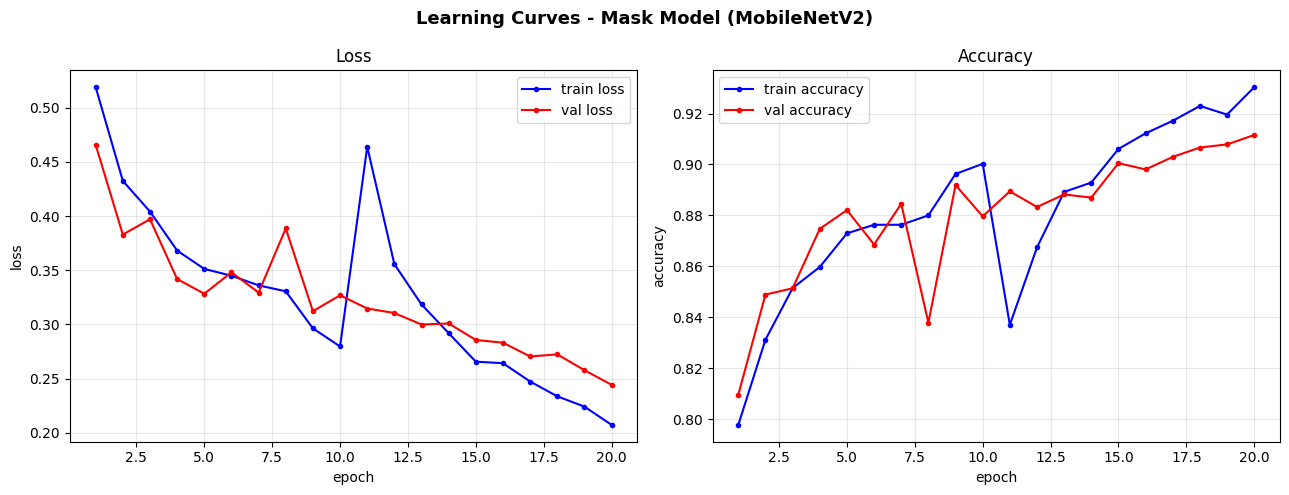

saved to outputs/learning_curve_mask.png


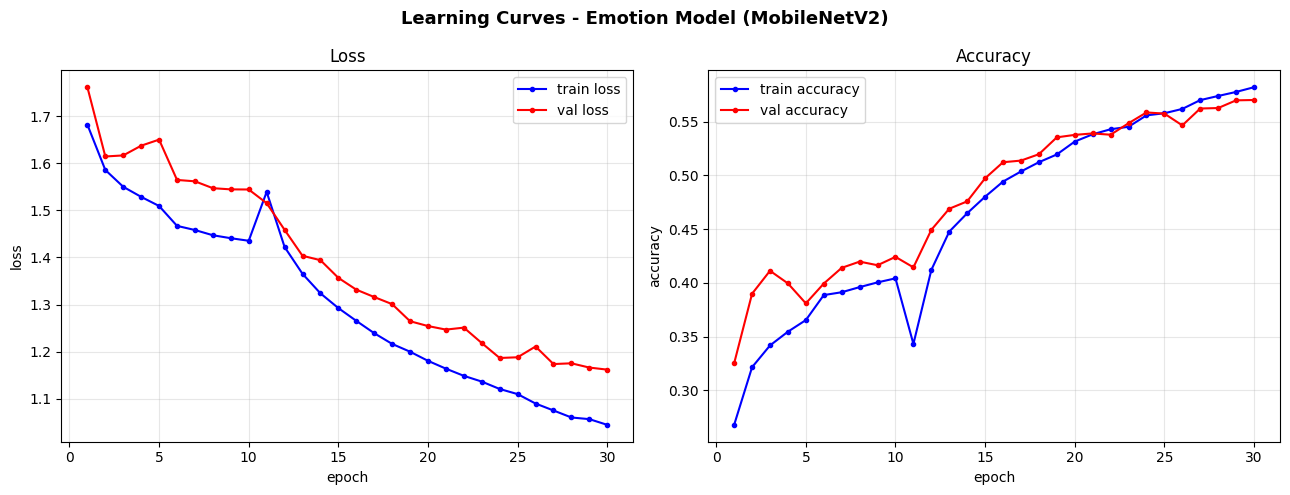

saved to outputs/learning_curve_emotion.png


In [38]:
def plot_learning_curves(history_dict, model_name, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Learning Curves - {model_name}', fontsize=13, fontweight='bold')

    epochs = range(1, len(history_dict['loss']) + 1)

    # loss
    axes[0].plot(epochs, history_dict['loss'], 'b-o', label='train loss', markersize=3)
    axes[0].plot(epochs, history_dict['val_loss'], 'r-o', label='val loss', markersize=3)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # accuracy
    axes[1].plot(epochs, history_dict['accuracy'], 'b-o', label='train accuracy', markersize=3)
    axes[1].plot(epochs, history_dict['val_accuracy'], 'r-o', label='val accuracy', markersize=3)
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f'saved to {save_path}')

plot_learning_curves(history_mask, 'Mask Model (MobileNetV2)', 'outputs/learning_curve_mask.png')
plot_learning_curves(history_emo,  'Emotion Model (MobileNetV2)', 'outputs/learning_curve_emotion.png')

## Step 8 - Evaluation

i will evaluate both models using:
- accuracy
- precision
- recall
- f1 score
- confusion matrix
- ROC-AUC (for mask model since it's binary)

In [39]:
# helper to get predictions from a generator
def predict_binary(model, generator):
    generator.reset()
    y_true = []
    y_proba = []
    for i in range(len(generator)):
        X, y = generator[i]
        preds = model.predict(X, verbose=0).flatten()
        y_true.extend(y.tolist())
        y_proba.extend(preds.tolist())
    y_true  = np.array(y_true)
    y_proba = np.array(y_proba)
    y_pred  = (y_proba >= 0.5).astype(int)
    return y_true, y_proba, y_pred

def predict_multiclass(model, generator):
    generator.reset()
    y_true = []
    y_pred = []
    for i in range(len(generator)):
        X, y = generator[i]
        preds = model.predict(X, verbose=0)
        y_true.extend(np.argmax(y, axis=1).tolist())
        y_pred.extend(np.argmax(preds, axis=1).tolist())
    return np.array(y_true), np.array(y_pred)

# get predictions
print('getting mask model predictions...')
mask_y_true, mask_y_proba, mask_y_pred = predict_binary(mask_model, mask_val)

print('getting emotion model predictions...')
emo_y_true, emo_y_pred = predict_multiclass(emo_model, emo_val)

print('done')

getting mask model predictions...
getting emotion model predictions...
done


In [40]:
# print metrics for mask model
mask_classes = ['without_mask', 'with_mask']

print('mask model evaluation')
print(f'accuracy : {accuracy_score(mask_y_true, mask_y_pred):.4f}')
print(f'precision: {precision_score(mask_y_true, mask_y_pred):.4f}')
print(f'recall   : {recall_score(mask_y_true, mask_y_pred):.4f}')
print(f'f1 score : {f1_score(mask_y_true, mask_y_pred):.4f}')
print(f'roc auc  : {roc_auc_score(mask_y_true, mask_y_proba):.4f}')
print()
print('detailed per-class report:')
print(classification_report(mask_y_true, mask_y_pred, target_names=mask_classes))

=== mask model evaluation ===
accuracy : 0.9115
precision: 0.8288
recall   : 0.7202
f1 score : 0.7707
roc auc  : 0.9587

detailed per-class report:
              precision    recall  f1-score   support

without_mask       0.93      0.96      0.95       646
   with_mask       0.83      0.72      0.77       168

    accuracy                           0.91       814
   macro avg       0.88      0.84      0.86       814
weighted avg       0.91      0.91      0.91       814



In [41]:
# print metrics for emotion model
print('emotion model evaluation')
print(f'accuracy : {accuracy_score(emo_y_true, emo_y_pred):.4f}')
print(f'precision: {precision_score(emo_y_true, emo_y_pred, average="weighted"):.4f}')
print(f'recall   : {recall_score(emo_y_true, emo_y_pred, average="weighted"):.4f}')
print(f'f1 score : {f1_score(emo_y_true, emo_y_pred, average="weighted"):.4f}')
print()
print('detailed per-class report:')
print(classification_report(emo_y_true, emo_y_pred, target_names=EMOTION_LABELS))

=== emotion model evaluation ===
accuracy : 0.5702
precision: 0.5700
recall   : 0.5702
f1 score : 0.5605

detailed per-class report:
              precision    recall  f1-score   support

       angry       0.46      0.47      0.47       888
     disgust       0.38      0.11      0.17        79
        fear       0.39      0.21      0.28       922
       happy       0.86      0.80      0.83      1711
     neutral       0.53      0.60      0.56      1182
         sad       0.47      0.46      0.47      1198
    surprise       0.48      0.84      0.61       581

    accuracy                           0.57      6561
   macro avg       0.51      0.50      0.48      6561
weighted avg       0.57      0.57      0.56      6561



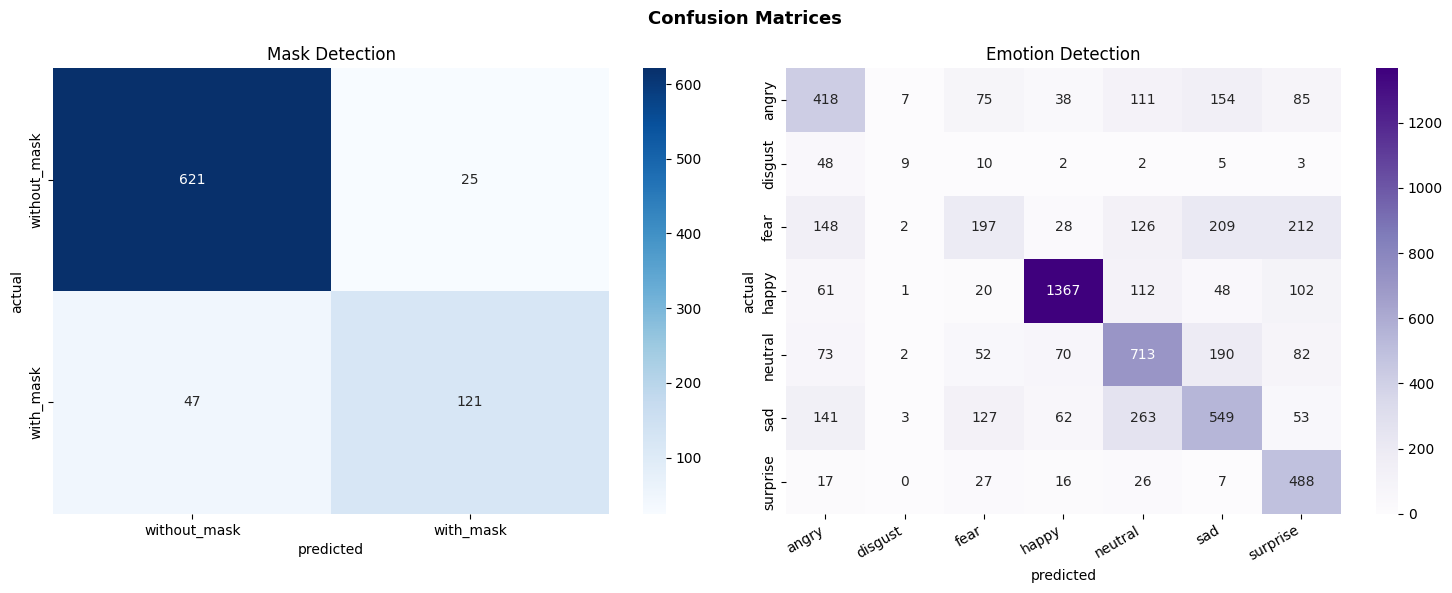

saved outputs/confusion_matrices.png


In [42]:
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

# mask confusion matrix
cm_mask = confusion_matrix(mask_y_true, mask_y_pred)
sns.heatmap(cm_mask, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=mask_classes, yticklabels=mask_classes)
axes[0].set_title('Mask Detection')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('actual')

# emotion confusion matrix
cm_emo = confusion_matrix(emo_y_true, emo_y_pred)
sns.heatmap(cm_emo, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
axes[1].set_title('Emotion Detection')
axes[1].set_xlabel('predicted')
axes[1].set_ylabel('actual')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png')
plt.show()
print('saved outputs/confusion_matrices.png')

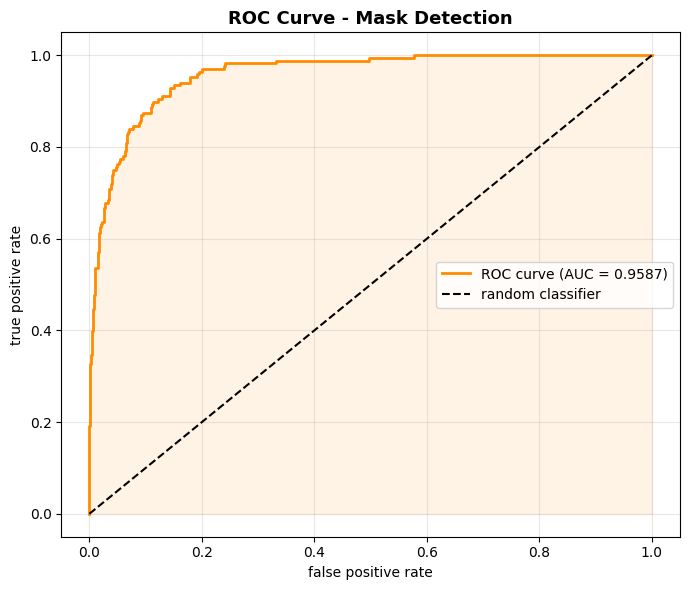

saved outputs/roc_curve_mask.png


In [43]:
# ROC curve for mask model (since it's binary classification)
auc_score = roc_auc_score(mask_y_true, mask_y_proba)
fpr, tpr, _ = roc_curve(mask_y_true, mask_y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC Curve - Mask Detection', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/roc_curve_mask.png')
plt.show()
print('saved outputs/roc_curve_mask.png')

## Baseline vs Transfer Learning Comparison

i will compare the simple CNN with the MobileNetV2 model to show that transfer learning is better.

In [44]:
# get baseline predictions
bl_mask_true, bl_mask_proba, bl_mask_pred = predict_binary(baseline_mask, mask_val)
bl_emo_true, bl_emo_pred                  = predict_multiclass(baseline_emo, emo_val_baseline)  # FIX: baseline was trained on 48x48 grayscale, not emo_val's 224x224

# build comparison table
comparison = {
    'model': [
        'Baseline CNN - Mask',
        'MobileNetV2  - Mask',
        'Baseline CNN - Emotion',
        'MobileNetV2  - Emotion'
    ],
    'accuracy': [
        round(accuracy_score(bl_mask_true, bl_mask_pred), 4),
        round(accuracy_score(mask_y_true, mask_y_pred), 4),
        round(accuracy_score(bl_emo_true, bl_emo_pred), 4),
        round(accuracy_score(emo_y_true, emo_y_pred), 4)
    ],
    'f1 score': [
        round(f1_score(bl_mask_true, bl_mask_pred), 4),
        round(f1_score(mask_y_true, mask_y_pred), 4),
        round(f1_score(bl_emo_true, bl_emo_pred, average='weighted'), 4),
        round(f1_score(emo_y_true, emo_y_pred, average='weighted'), 4)
    ],
    'roc auc': [
        round(roc_auc_score(bl_mask_true, bl_mask_proba), 4),
        round(roc_auc_score(mask_y_true, mask_y_proba), 4),
        'n/a', 'n/a'
    ]
}

comp_df = pd.DataFrame(comparison)
print('=== BASELINE vs TRANSFER LEARNING ===')
print(comp_df.to_string(index=False))

=== BASELINE vs TRANSFER LEARNING ===
                 model  accuracy  f1 score roc auc
   Baseline CNN - Mask    0.9349    0.8437  0.9751
   MobileNetV2  - Mask    0.9115    0.7707  0.9587
Baseline CNN - Emotion    0.6063    0.6032     n/a
MobileNetV2  - Emotion    0.5702    0.5605     n/a


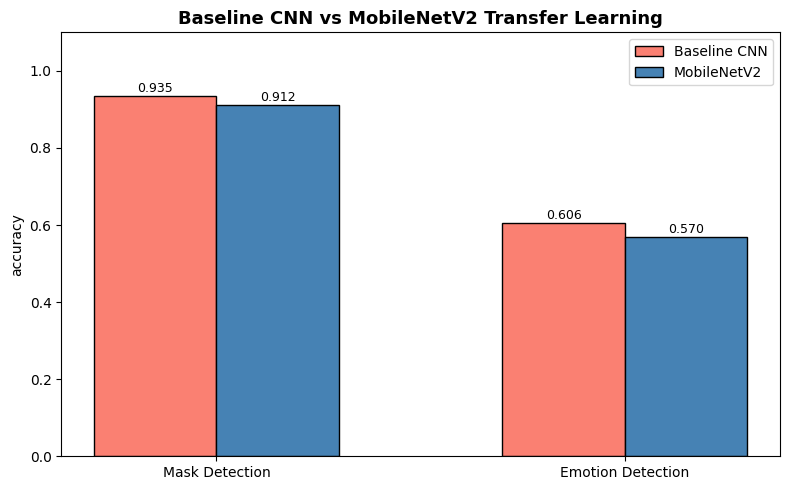

saved outputs/baseline_vs_transfer.png


In [45]:
# bar chart comparison
labels  = ['Mask Detection', 'Emotion Detection']
bl_accs = [accuracy_score(bl_mask_true, bl_mask_pred),
            accuracy_score(bl_emo_true, bl_emo_pred)]
tl_accs = [accuracy_score(mask_y_true, mask_y_pred),
            accuracy_score(emo_y_true, emo_y_pred)]

x = np.arange(len(labels))
w = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, bl_accs, w, label='Baseline CNN', color='salmon', edgecolor='black')
bars2 = ax.bar(x + w/2, tl_accs, w, label='MobileNetV2', color='steelblue', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('accuracy')
ax.set_title('Baseline CNN vs MobileNetV2 Transfer Learning', fontsize=13, fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/baseline_vs_transfer.png')
plt.show()
print('saved outputs/baseline_vs_transfer.png')

In [46]:
# save the final models
mask_model.save('models/mask_model_final.h5')
emo_model.save('models/emotion_model_final.h5')

print('models saved:')
print('  models/mask_model_final.h5')
print('  models/emotion_model_final.h5')
print()
print('download these files and put them in the models/ folder locally')
print('then run app.py for the live webcam demo')

models saved:
  models/mask_model_final.h5
  models/emotion_model_final.h5

download these files and put them in the models/ folder locally
then run app.py for the live webcam demo


## Summary

what i did in this notebook:

| step | what i did |
|------|------------|
| data prep | cropped face ROIs from mask dataset, set up ImageDataGenerators with augmentation |
| baseline  | trained simple 3-block CNN for mask and emotion (for comparison) |
| transfer  | used MobileNetV2 pretrained on ImageNet, added custom head |
| overfitting | added dropout, L2 regularization, early stopping, ReduceLR |
| fine-tuning | unfroze last 30 layers and retrained with small learning rate |
| evaluation | accuracy, precision, recall, F1, confusion matrix, ROC-AUC |
| comparison | baseline CNN vs MobileNetV2 side by side |

the models are saved in the `models/` folder.
download them and put in your local repo, then run `app.py`.